# Customer Trends & Diagnostics EDA

This notebook is split from `02_customer_behavior.ipynb` for maintainability.


## Notebook Roadmap

1. Data Setup & KPI Baseline
2. Bivariate Behavior Comparison
3. Time-slot Pattern (Day x Hour)
4. Customer Segmentation (User-level)
5. Segment Preferences (Product / Aisle)
6. Retention & Churn
7. Basket Value by Category
8. CLV Trends & Segment CLV
9. Extra Diagnostics (Funnel / Gateway / Trend / Histogram)
10. Executive Summary

Run guide:
- ตั้งค่า `USE_SAMPLE` ที่ cell โหลดข้อมูล
- รันจากบนลงล่างเพื่อให้ตัวแปรกลาง (เช่น `rfm`, `segment_txn`, `customer_monthly`) พร้อมใช้งานครบ

In [1]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Display formatting (readable numbers in notebook output) ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

def show_df(df, title=None, n=PREVIEW_ROWS):
    """Display full table only in verbose mode; otherwise show top-N preview."""
    if title:
        print(title)
    display(df if SHOW_VERBOSE_TABLES else df.head(n))

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 32,434,489 records with 206,209 unique customers
Date range: 2014-07-01 to 2015-07-01
Data mode: FULL DATASET
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,aisle_id,department_id,aisle,department,total_price,cumulative_reorder_per_customer
0,2539329,196,1,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Soda,77,7,soft drinks,beverages,1,0
1,2539329,14084,2,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Organic Unsweetened Vanilla Almond Milk,91,16,soy lactosefree,dairy eggs,1,0
2,2539329,12427,3,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Original Beef Jerky,23,19,popcorn jerky,snacks,1,0
3,2539329,26088,4,0,1,prior,1,2,8,0.0,0.0,2014-12-23,Aged White Cheddar Popcorn,23,19,popcorn jerky,snacks,1,0
4,2539329,26405,5,0,1,prior,1,2,8,0.0,0.0,2014-12-23,XL Pick-A-Size Paper Towel Rolls,54,17,paper goods,household,1,0


## 3) Segmentation & Customer Value Lens

### 3.1 Customer Segmentation (User-level features)

สร้างกลุ่มลูกค้าจาก **User-level features** เพื่อวิเคราะห์ "ความต่าง" ของพฤติกรรมให้ชัดขึ้น

Features หลัก:
- `total_orders` = จำนวนครั้งที่สั่งซื้อ
- `avg_basket_size` = จำนวนสินค้าเฉลี่ยต่อตะกร้า
- `reorder_ratio` = อัตราการซื้อซ้ำ
- `days_since_last_order` = วันตั้งแต่สั่งครั้งล่าสุด

Logic การแบ่ง Segment (แบบเรียบง่ายและตีความง่าย):
- **Whales**: ลูกค้าที่สั่งบ่อยมาก (`total_orders` อยู่ใน Top 10%)
- **Regulars**: ลูกค้าทั่วไป
- **Churned**: ลูกค้าที่ไม่ได้สั่งมานานเกิน 30 วัน

หมายเหตุ: ถ้าลูกค้าเข้าเงื่อนไข Churned จะถูกจัดเป็น `Churned` แม้จะเคยสั่งบ่อย (override เพื่อเน้นสถานะล่าสุด)

#### 3.2 Segment Distribution Check

In [2]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

# 1) Order frequency + reorder behavior + recency per user
user_order_profile = (
    df.groupby("user_id", observed=False)
    .agg(
        total_orders=("order_id", "nunique"),
        reorder_ratio=("reordered", "mean"),
        last_order_date=("order_date", "max"),
    )
    .reset_index()
)

# 2) Basket size per order -> average basket size at user level
order_basket = (
    df.groupby(["user_id", "order_id"], observed=False)
    .agg(basket_size=("product_id", "count"))
    .reset_index()
)

user_basket_profile = (
    order_basket.groupby("user_id", observed=False)
    .agg(avg_basket_size=("basket_size", "mean"))
    .reset_index()
)

# Keep variable name `rfm` for downstream compatibility in this notebook.
rfm = user_order_profile.merge(user_basket_profile, on="user_id", how="left")
rfm["days_since_last_order"] = (snapshot_date - rfm["last_order_date"]).dt.days

# Segment rules
whale_threshold = rfm["total_orders"].quantile(0.90)
rfm["segment"] = "Regulars"
rfm.loc[rfm["total_orders"] >= whale_threshold, "segment"] = "Whales"
rfm.loc[rfm["days_since_last_order"] > 30, "segment"] = "Churned"

segment_order = ["Whales", "Regulars", "Churned"]
rfm["segment"] = pd.Categorical(rfm["segment"], categories=segment_order, ordered=True)

print(f"Whale threshold (Top 10% total_orders): {whale_threshold:,.2f}")
show_df(rfm[["user_id", "total_orders", "avg_basket_size", "reorder_ratio", "days_since_last_order", "segment"]], title="User-level segmentation sample:")

segment_summary = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_avg_basket_size=("avg_basket_size", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)

print("Segment summary:")
show_df(segment_summary)

Whale threshold (Top 10% total_orders): 37.00
User-level segmentation sample:


,user_id,total_orders,avg_basket_size,reorder_ratio,days_since_last_order,segment
0,1,10,5.900000,0.694915,15,Regulars
1,2,14,13.928571,0.476923,31,Churned
2,3,12,7.333333,0.625000,12,Regulars
3,4,5,3.600000,0.055556,31,Churned
4,5,4,9.250000,0.378378,7,Regulars
5,6,3,4.666667,0.142857,23,Regulars
6,7,20,10.300000,0.669903,7,Regulars
7,8,3,16.333333,0.265306,11,Regulars
8,9,3,25.333333,0.236842,31,Churned
9,10,5,28.600000,0.342657,31,Churned


Segment summary:


,segment,users,median_total_orders,median_avg_basket_size,median_reorder_ratio,median_days_since_last_order
0,Whales,20024,51.0,9.33737,0.727273,7.0
1,Regulars,122999,10.0,9.03125,0.431373,12.0
2,Churned,63186,6.0,8.50000,0.341463,31.0


Executive Summary: Customer Segmentation & Behavioral Insight

จากการวิเคราะห์พฤติกรรมลูกค้าผ่านตาราง Segment Summary พบว่าเครื่องยนต์หลักที่ขับเคลื่อนธุรกิจนี้คือ "ความถี่ (Frequency)" และ "ความเชื่อมั่นในสินค้าเดิม (Reorder Loyalty)" โดยมีรายละเอียดดังนี้:
1. The Power of "Whales" (High-Frequency Engine)

    Loyalty is Key: กลุ่ม Whales ไม่ได้ซื้อของเยอะกว่าคนอื่นต่อครั้ง (basket_size ใกล้เคียงกันที่ ~9 ชิ้น) แต่พวกเขาซื้อ "บ่อย" กว่ามาก โดยสั่งซื้อเฉลี่ยถึง 51 ครั้ง

    Habitual Buying: มี reorder_ratio สูงถึง 72% สะท้อนว่าลูกค้ากลุ่มนี้มี "List สินค้าประจำ" ในใจอยู่แล้ว การทำการตลาดกับกลุ่มนี้ควรเน้นไปที่การรักษาความสะดวก (Convenience) มากกว่าการลดราคา

2. The "Regulars" Opportunity (The Growth Lever)

    The 12-Day Window: กลุ่ม Regulars มีรอบการสั่งซื้ออยู่ที่ 12 วัน (Median) ซึ่งช้ากว่า Whales เกือบเท่าตัว

    Upselling Potential: นี่คือกลุ่มฐานใหญ่ที่สุด (1.2 แสนราย) หากสามารถทำ Personalized Notification เพื่อกระตุ้นให้พวกเขากลับมาซื้อซ้ำในวันที่ 8-10 (ก่อนถึงรอบปกติ) จะสามารถดึงรายได้มหาศาลกลับมาสู่บริษัทได้

3. Early Churn Detection (The Red Flag)

    The 31-Day Danger Zone: เมื่อลูกค้าเงียบหายไปเกิน 30 วัน อัตราการซื้อซ้ำจะตกลงเหลือเพียง 34% * Behavioral Shift: สังเกตว่ากลุ่ม Churned ไม่ได้แค่ซื้อน้อยลง แต่ "ความแม่นยำ" ในการกลับมาซื้อของเดิมก็น้อยลงด้วย (reorder_ratio ต่ำสุด) แสดงถึงความพึงพอใจในตัวสินค้าที่ลดลง

In [3]:
# เชื่อมโยง Segment กลับไปที่ Data หลัก
df = df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")

# ตรวจสอบว่ารวมสำเร็จไหม
show_df(df.groupby("segment").size().to_frame("rows"), title="Rows by segment:")

Rows by segment:


,rows
segment,
Whales,11472267
Regulars,15743925
Churned,5218297


### ความหนาแน่นของข้อมูล (Data Density)

เมื่อพิจารณาความหนาแน่นของข้อมูลในแต่ละกลุ่มลูกค้า จะเห็นความแตกต่างอย่างชัดเจนดังนี้

- **Whales** มีลูกค้าเพียง **20,024 คน** แต่สร้างข้อมูลสูงถึง **11.4 ล้านแถว**  
  คิดเป็นค่าเฉลี่ยประมาณ **570 แถวต่อคน** สะท้อนให้เห็นว่าลูกค้ากลุ่มนี้มีพฤติกรรมการซื้อที่เข้มข้นและเกิดธุรกรรมบ่อยกว่ากลุ่มอื่นอย่างมาก

- **Regulars** มีจำนวนมากที่สุดถึง **122,999 คน** แต่สร้างข้อมูลรวม **15.7 ล้านแถว**  
  หรือเฉลี่ยประมาณ **128 แถวต่อคน** แสดงให้เห็นว่าถึงแม้จะมีฐานลูกค้าขนาดใหญ่ แต่ความหนาแน่นของข้อมูลต่อคนยังต่ำกว่า Whales อย่างชัดเจน

- **Churned** มีจำนวน **63,186 คน** และสร้างข้อมูล **5.2 ล้านแถว**  
  เฉลี่ยเพียงประมาณ **82 แถวต่อคน** ซึ่งเป็นค่าต่ำสุด สะท้อนถึงระดับการมีส่วนร่วมหรือความถี่ในการซื้อที่ลดลง

"แม้กลุ่ม Whales จะมีจำนวนสมาชิกน้อยที่สุด แต่กลับเป็นกลุ่มที่สร้าง Data Footprint สูงที่สุดในระบบ โดยเฉลี่ยแล้ว Whale 1 คนสร้างข้อมูลพฤติกรรมมากกว่ากลุ่ม Churned ถึง 7 เท่า ข้อมูลนี้สะท้อนว่าคุณภาพของ Dataset ชุดนี้มีความหนาแน่นสูงมากในกลุ่มลูกค้าชั้นดี ซึ่งเป็นโอกาสสำคัญในการทำ Precision Marketing แต่ก็เป็นความท้าทายในการจัดการ Computational Resource เมื่อต้องประมวลผลข้อมูลกว่า 32 ล้านรายการ

#### 3.5 Segment Spend Sanity Check

In [5]:
# ดูสินค้า Top 3 ของแต่ละ Segment
rows = []
for seg in segment_order:
    top_prods = (
        df[df["segment"] == seg]["product_name"]
        .value_counts()
        .head(3)
        .rename("order_lines")
        .reset_index()
        .rename(columns={"index": "product_name"})
    )
    top_prods["segment"] = seg
    rows.append(top_prods)

top3_by_segment = pd.concat(rows, ignore_index=True)
show_df(top3_by_segment[["segment", "product_name", "order_lines"]], title="Top 3 products by segment:")

Top 3 products by segment:


,segment,product_name,order_lines
0,Whales,Banana,173181
1,Whales,Bag of Organic Bananas,159961
2,Whales,Organic Strawberries,115698
3,Regulars,Banana,220255
4,Regulars,Bag of Organic Bananas,173106
5,Regulars,Organic Baby Spinach,116074
6,Churned,Banana,79129
7,Churned,Bag of Organic Bananas,46383
8,Churned,Organic Baby Spinach,37021


#### 3.6 Segment Product Breadth

<Axes: xlabel='order_dow', ylabel='segment'>

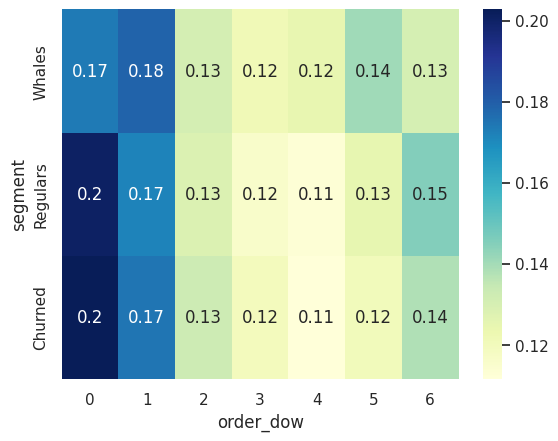

In [6]:
# กลุ่มไหนสั่งวันเสาร์-อาทิตย์ เยอะกว่ากัน?
day_dist = pd.crosstab(df['segment'], df['order_dow'], normalize='index')
# แสดงผลเป็น Heatmap จะดูง่ายมาก
import seaborn as sns
sns.heatmap(day_dist, annot=True, cmap="YlGnBu")

### 3.7 Product Preferences by Segment
ใช้ transaction-level data ที่ join กับ segment จากตาราง user-level เพื่ออ่านพฤติกรรมสินค้าอย่างถูกบริบท

ตีความเชิงธุรกิจจากความชอบสินค้าแต่ละ segment

- Whales: สินค้า/หมวดหมู่ที่สั่งบ่อยและมีสัดส่วนสูง
- Regulars: สินค้าฐานกว้างที่สร้าง volume
- Churned: หมวดหมู่ที่อาจใช้ทำ win-back campaign

Use case:
- Recommendation
- Merchandising
- Segment-specific Marketing

#### 3.8 Segment Preference Charts

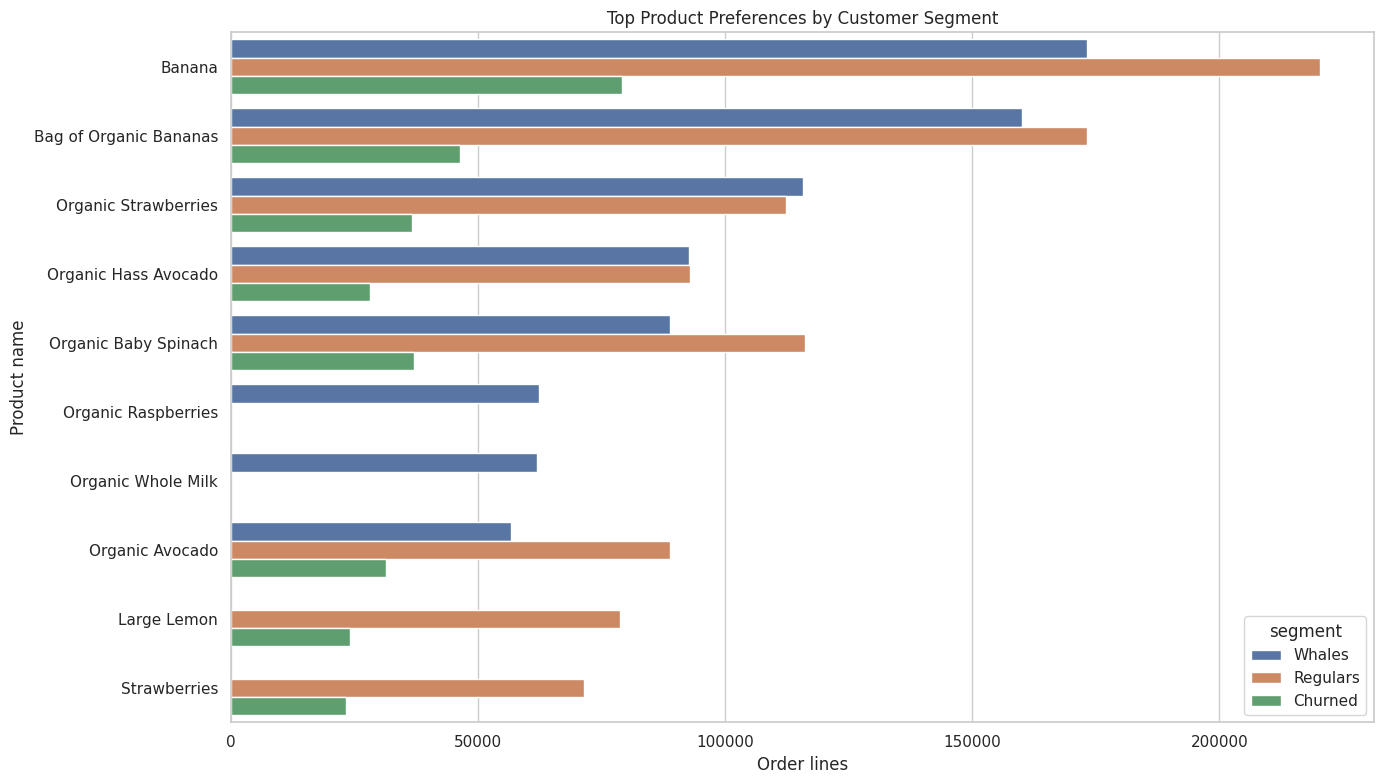

Top products by segment:


,segment,product_name,order_lines
0,Whales,Banana,173181
1,Whales,Bag of Organic Bananas,159961
2,Whales,Organic Strawberries,115698
3,Whales,Organic Hass Avocado,92728
4,Whales,Organic Baby Spinach,88826
5,Whales,Organic Raspberries,62354
6,Whales,Organic Whole Milk,61899
7,Whales,Organic Avocado,56586
8,Regulars,Banana,220255
9,Regulars,Bag of Organic Bananas,173106


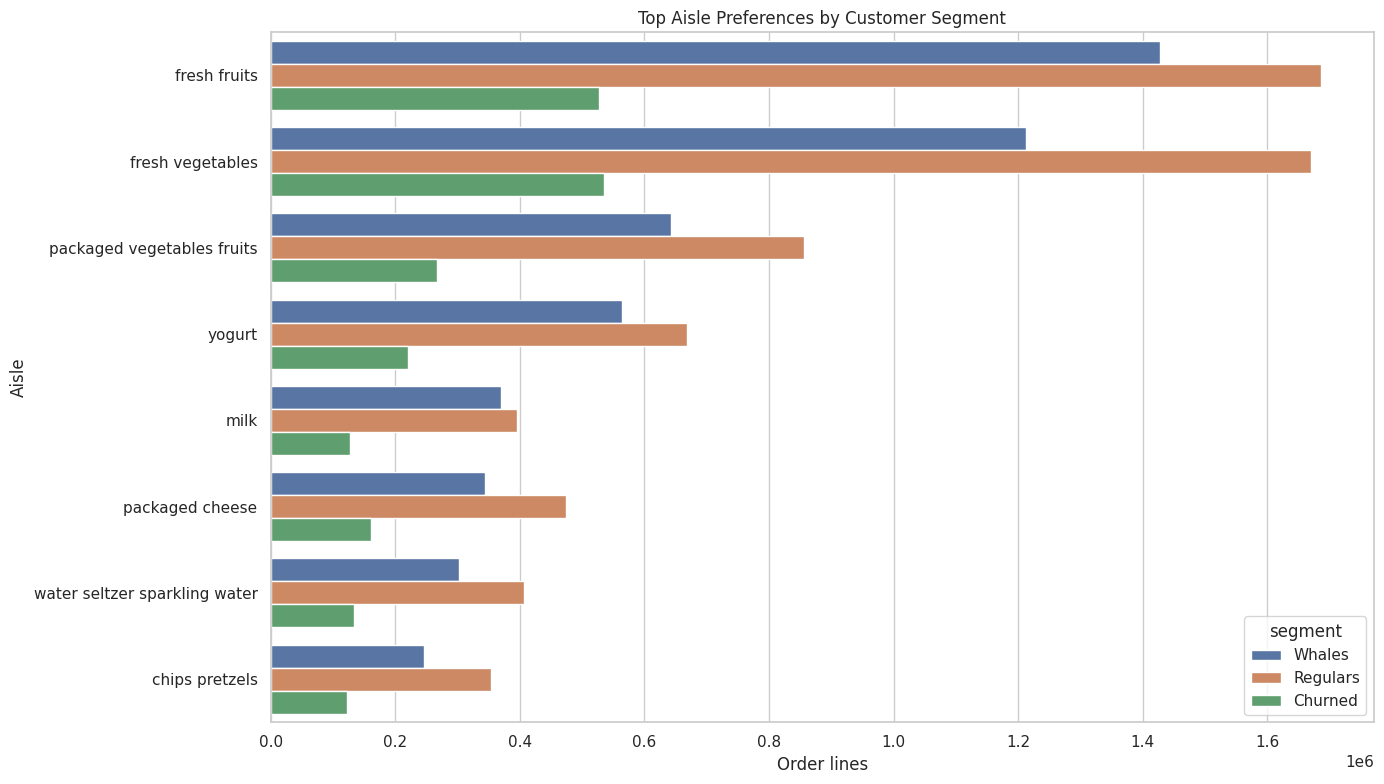

Top aisles by segment:


,segment,aisle,order_lines
0,Whales,fresh fruits,1427983
1,Whales,fresh vegetables,1212191
2,Whales,packaged vegetables fruits,642313
3,Whales,yogurt,564345
4,Whales,milk,368884
5,Whales,packaged cheese,344656
6,Whales,water seltzer sparkling water,301618
7,Whales,chips pretzels,246368
8,Regulars,fresh fruits,1686941
9,Regulars,fresh vegetables,1670578


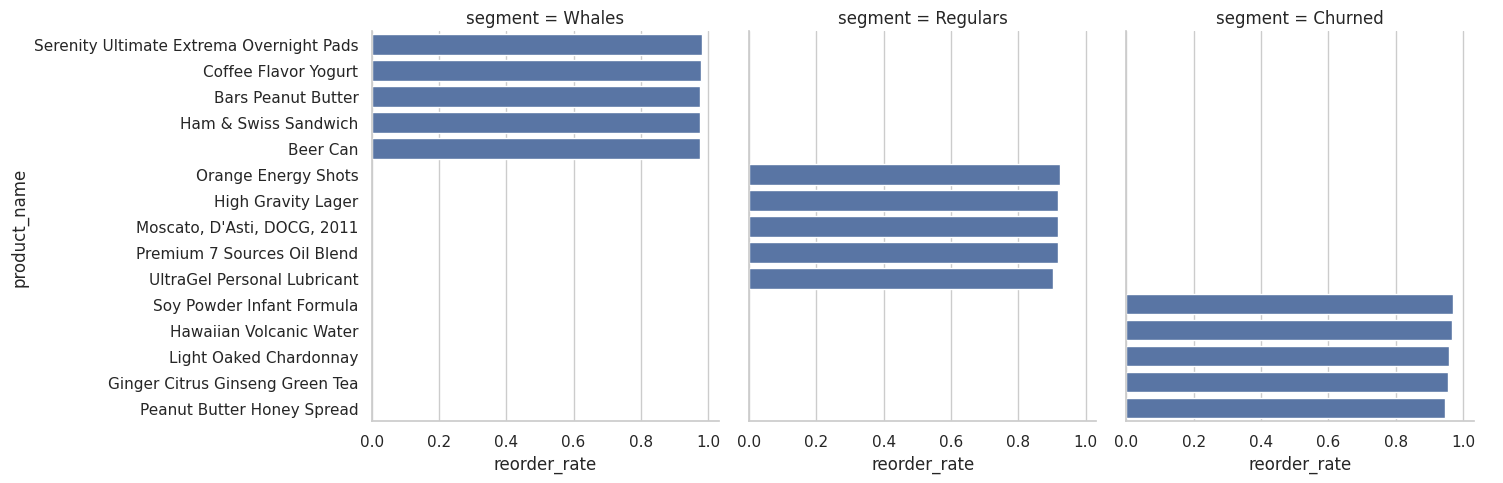

Median reorder_rate by segment:


,median_reorder_rate
segment,
Whales,0.976190
Regulars,0.916667
Churned,0.960000


In [7]:
segment_txn = df.copy()

# Use existing segment if already merged into df; otherwise bring from rfm.
if "segment" not in segment_txn.columns:
    segment_txn = segment_txn.merge(
        rfm[["user_id", "segment"]],
        on="user_id",
        how="left",
    )

# Ensure aisle exists for aisle-level preference analysis.
if "aisle" not in segment_txn.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "aisle"]]
    segment_txn = segment_txn.merge(product_dim, on="product_id", how="left")

segment_product_pref = (
    segment_txn.groupby(["segment", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_products_by_segment = (
    segment_product_pref.sort_values(
        ["segment", "order_lines", "product_name"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

segment_aisle_pref = (
    segment_txn.dropna(subset=["aisle"])
    .groupby(["segment", "aisle"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_aisle_by_segment = (
    segment_aisle_pref.sort_values(
        ["segment", "order_lines", "aisle"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

top_reordered_by_segment = (
    segment_txn.groupby(["segment", "product_name"], observed=False)
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

top_reordered_by_segment = (
    top_reordered_by_segment
    .sort_values(["segment", "reorder_rate"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(5)
)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_products_by_segment,
    x="order_lines",
    y="product_name",
    hue="segment",
)
plt.title("Top Product Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Product name")
plt.tight_layout()
plt.show()

show_df(top_products_by_segment, title="Top products by segment:")

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_aisle_by_segment,
    x="order_lines",
    y="aisle",
    hue="segment",
)
plt.title("Top Aisle Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()

show_df(top_aisle_by_segment, title="Top aisles by segment:")

sns.catplot(
    data=top_reordered_by_segment,
    x="reorder_rate",
    y="product_name",
    col="segment",
    kind="bar",
    height=5,
    aspect=1,
)
plt.show()

# Keep summary concise in clean mode.
if SHOW_VERBOSE_TABLES:
    print(top_reordered_by_segment.groupby("segment")["reorder_rate"].describe())
else:
    print("Median reorder_rate by segment:")
    display(top_reordered_by_segment.groupby("segment", observed=False)["reorder_rate"].median().to_frame("median_reorder_rate"))

Deep Dive: Customer Product Preferences & Strategic Insights

จากการวิเคราะห์สินค้าที่ได้รับความนิยมสูงสุดแยกตาม Segment พบว่ามีรูปแบบพฤติกรรมที่น่าสนใจและสามารถนำไปวางกลยุทธ์ต่อได้ดังนี้:
1. The "Organic" Dominance (Common Behavior)

    Insight: สินค้าที่ทุกกลุ่มซื้อเหมือนกันคือกลุ่ม Fresh Produce (กล้วย, สตรอว์เบอร์รี, อะโวคาโด) โดยเฉพาะสินค้าที่เป็น Organic

    DS Perspective: สินค้ากลุ่มนี้คือ "Anchor Products" หรือสินค้าดึงดูดลูกค้า แม้แต่กลุ่ม Churned ก็ยังซื้อสินค้าเหล่านี้ก่อนจะเลิกใช้บริการ แสดงว่าคุณภาพและราคาของสินค้ากลุ่มนี้มีผลอย่างมากต่อการตัดสินใจเริ่มสั่งซื้อ

2. Segment-Specific Nuances (Product Breadth)

    Whales (Organic & Essentials): กลุ่ม Whales มีความโดดเด่นในการซื้อ Organic Whole Milk และ Organic Raspberries สูงกว่ากลุ่มอื่นอย่างเห็นได้ชัด

        Interpretation: สะท้อนว่า Whales มักเป็นกลุ่ม Household ที่ให้ความสำคัญกับสุขภาพและมีกำลังซื้อสูง (High-value basket)

    Regulars (The Volume Drivers): เป็นกลุ่มที่มียอดสั่งซื้อ Banana และ Bag of Organic Bananas สูงที่สุดในเชิงจำนวนบรรทัด (Rows) ยืนยันว่ากลุ่มนี้คือแหล่งรายได้หลักในเชิงปริมาณ (Volume)

3. Strategy Map & Behavioral Link

    เมื่อนำข้อมูลนี้ไปรวมกับ Strategy Map จะเห็นว่า:

        Whales: มูลค่าต่อหัว (Intensity) สูง เพราะซื้อสินค้าพรีเมียม (Organic Milk/Berries) อย่างต่อเนื่อง

        Regulars: จำนวนผู้ใช้ (Volume) เยอะ และเน้นซื้อสินค้าพื้นฐาน (Bananas) ในปริมาณมาก

        Churned: แม้จะหายไปแล้ว แต่ประวัติการซื้อยังโชว์ว่าเขาสนใจสินค้ากลุ่ม Organic เช่นกัน แต่อาจจะยังไม่ขยายไปซื้อสินค้าหมวดหมู่อื่น (Low Product Breadth)


Product-Level Reorder Analysis: Deep Behavioral Signature

จากการวิเคราะห์สินค้าที่มีอัตราการซื้อซ้ำ (Reorder Rate) สูงสุดแยกตาม Segment พบว่าแต่ละกลุ่มมีพฤติกรรมการบริโภคที่ "จำเพาะเจาะจง" และสามารถสะท้อนไลฟ์สไตล์ได้ดังนี้:
1. Whales: The "Routine Essentials" Segment

    Product Traits: สินค้าที่มี Reorder Rate เกือบเต็ม 1.00 (100%) ในกลุ่มนี้คือสินค้าที่ใช้ในชีวิตประจำวันและต้องมีการเติมสต็อกบ่อยครั้ง เช่น Coffee Flavor Yogurt, Ham & Swiss Sandwich, และ Bars Peanut Butter

    Insight: กลุ่ม Whales ใช้แพลตฟอร์มนี้เพื่อซื้อสินค้ากลุ่ม "Ready-to-eat" และ "Daily Snacks" ซึ่งอธิบายได้ว่าทำไมพวกเขาถึงมีพฤติกรรมการซื้อที่ถี่มาก (7 วันต่อครั้ง)

2. Regulars: The "Energy & Lifestyle" Segment

    Product Traits: สินค้าที่มีอัตราการซื้อซ้ำสูงในกลุ่มนี้มีความหลากหลายกว่า เช่น Orange Energy Shots, High Gravity Lager, และ Moscato

    Insight: กลุ่ม Regulars มักซื้อสินค้ากลุ่มเครื่องดื่มและสินค้าไลฟ์สไตล์ที่มีความถี่ในการบริโภคปานกลาง ซึ่งสอดคล้องกับรอบการสั่งซื้อ 12 วันของพวกเขา

3. Churned: The "Specific Needs" Segment

    Product Traits: น่าสนใจที่กลุ่ม Churned มีสินค้าที่มี Reorder Rate สูงมาก (เกือบ 1.00) เช่นกัน เช่น Soy Powder Infant Formula และ Hawaiian Volcanic Water

    Insight: กลุ่มนี้อาจจะเข้ามาเพื่อซื้อสินค้าที่ "เฉพาะเจาะจงมาก" (Specialized Products) เมื่อความต้องการในสินค้านั้นจบลง หรือพบช่องทางซื้ออื่นที่สะดวกกว่า พวกเขาก็มีโอกาส Churn สูง

Retention Strategy (Whales): สำหรับกลุ่มที่มี Value สูงสุด ควรเน้นระบบ "One-click Reorder" สำหรับสินค้ากลุ่ม Deli และ Snacks เพราะเป็นสินค้าที่พวกเขากลับมาซื้อซ้ำเป็นกิจวัตรเกือบ 100%

Conversion Strategy (Regulars): ควรใช้ระบบแนะนำสินค้ากลุ่ม Healthy Snacks (จากฐานข้อมูล Whales) เข้าไปเสริมกับกลุ่มเครื่องดื่มที่พวกเขาชอบซื้ออยู่แล้ว เพื่อเพิ่มมูลค่าตะกร้าสินค้า

Win-back Strategy (Churned): การที่พวกเขามี Reorder Rate สูงในสินค้าเด็ก (Infant Formula) แสดงว่าเขามีความ Loyalty ต่อตัวสินค้าสูงมาก หากส่งโปรโมชั่นที่เกี่ยวกับ "การเติบโตของเด็ก" (สินค้าขั้นถัดไป) อาจจะดึงพวกเขากลับมาได้

ความสมเหตุสมผม ของข้อมูล : 
1. การเชื่อมโยง "สินค้า" กับ "ความถี่" (Product vs. Frequency)

    สิ่งที่คุณเห็นก่อนหน้า: กลุ่ม Whales สั่งซื้อบ่อยมากทุกๆ 7 วัน และมี Reorder Ratio สูงถึง 72%

    ความเชื่อมโยงจากภาพใหม่: สินค้าที่ Whales ซื้อซ้ำเกือบ 100% คือ Yogurt, Sandwich, และ Peanut Butter ซึ่งเป็นสินค้ากลุ่ม "Ready-to-eat" หรืออาหารที่กินแล้วหมดไปรายวัน

    บทสรุป: ข้อมูลไม่ขัดแย้งกัน เพราะการที่เขาซื้อของที่ "ต้องกินทุกวัน" จึงเป็นเหตุผลรองรับว่าทำไมเขาถึงต้อง "กลับมาสั่งทุกสัปดาห์" นั่นเองครับ

2. การเชื่อมโยง "กลุ่มสินค้า" กับ "ความคุ้มค่าต่อหัว" (Value per User)

    สิ่งที่คุณเห็นก่อนหน้า: กลุ่ม Whales มีมูลค่าต่อหัว (Avg Value) สูงกว่ากลุ่มอื่นเกือบ 4-5 เท่า

    ความเชื่อมโยงจากภาพใหม่: ในขณะที่ Regulars เน้นซื้อกล้วย (สินค้าพื้นฐาน) แต่ Whales กลับซื้อสินค้ากลุ่ม Premium/Specific เช่น Organic Whole Milk, Organic Raspberries และสินค้า Deli

    บทสรุป: สอดคล้องกัน 100% เพราะสินค้ากลุ่ม Organic และ Deli มักมีราคาสูงกว่ากล้วยทั่วไป จึงทำให้มูลค่าต่อหัวของ Whales พุ่งสูงขึ้นอย่างสมเหตุสมผลครับ

3. การเชื่อมโยง "พฤติกรรม Churned" (The Churn Logic)

    สิ่งที่คุณเห็นก่อนหน้า: กลุ่ม Churned มีการสั่งซื้อที่หยุดนิ่งไปเกิน 30 วัน

    ความเชื่อมโยงจากภาพใหม่: สินค้าที่กลุ่ม Churned เคยซื้อซ้ำหนักๆ คือ Infant Formula (นมผงเด็ก)

    บทสรุป: นี่คือ Insight ที่ลึกมาก เพราะนมผงเด็กเป็นสินค้าที่มี "ช่วงเวลาการใช้งาน" (Window of Need) จำกัด เมื่อเด็กโตขึ้น ลูกค้ากลุ่มนี้จึงเลิกซื้อและ Churn ออกจากระบบไปหากเราไม่มีสินค้าขั้นถัดไปรองรับ

### 6.1 Days Between Orders Distribution by Segment

วิเคราะห์ cadence ของแต่ละ segment ด้วย `days_since_prior_order` แบบ customer-median เพื่อลด noise จาก order รายครั้ง

- Distribution plot: เปรียบเทียบ density ในภาพเดียว
- Box plot: ดู median / IQR / spread ต่อกลุ่ม
- Summary table: customers, median, mean, std, p25, p75

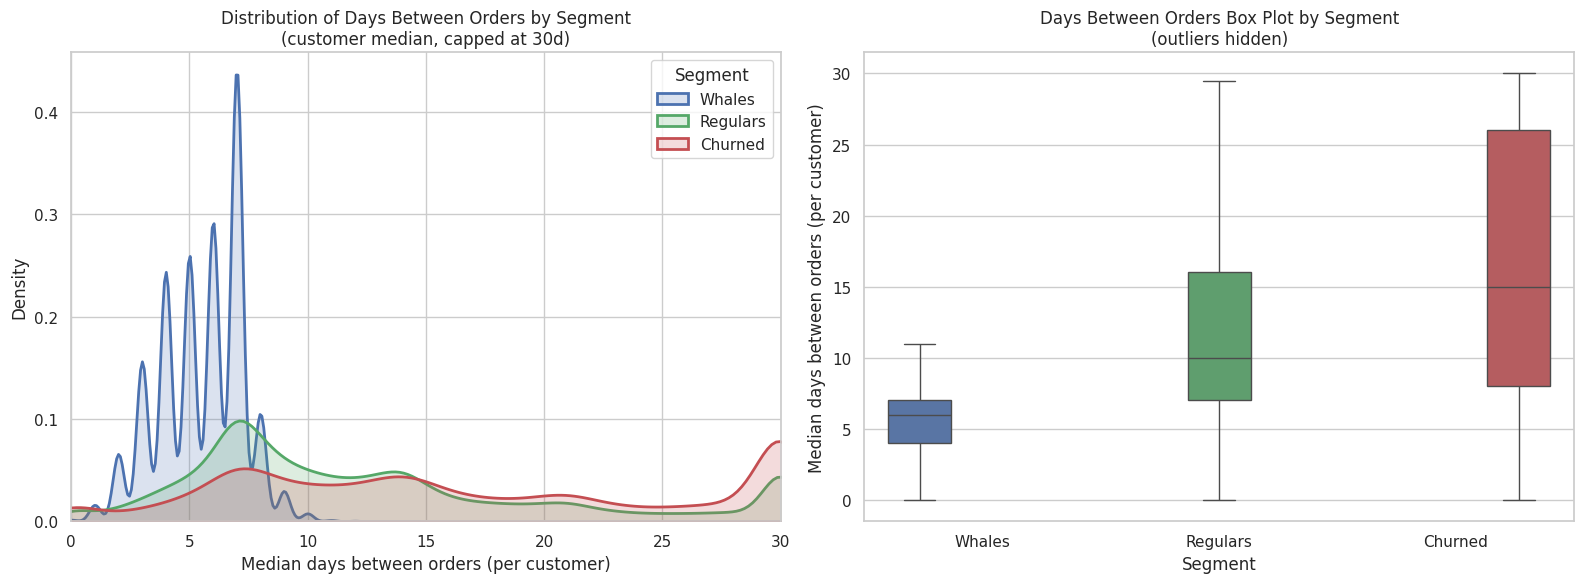

Days between orders summary by segment:


,segment,customers,median,mean,std,p25,p75
0,Whales,20024,6.0,5.517030,1.769028,4.0,7.0
1,Regulars,122999,10.0,12.579074,7.883809,7.0,16.0
2,Churned,63186,15.0,16.461479,9.282493,8.0,26.0



กลุ่มที่สั่งซื้อถี่ที่สุด: Whales (median = 6.0 วัน, IQR = 4.0–7.0)


In [11]:
# --- Days between orders distribution per segment ---
# Use customer-level median to represent each customer's "typical" gap.
# This avoids noise from the first order (NaN days) and large purchase streaks.

days_df = (
    df[df["days_since_prior_order"].notna()]
    .groupby("user_id", observed=False)
    .agg(customer_median_days=("days_since_prior_order", "median"))
    .reset_index()
    .merge(rfm[["user_id", "segment"]], on="user_id", how="left")
)
days_df["segment"] = days_df["segment"].fillna("Unknown")

DAYS_CAP = 30  # cap at 30 for readability; 30d = monthly cadence max
days_plot = days_df.copy()
days_plot["customer_median_days"] = days_plot["customer_median_days"].clip(upper=DAYS_CAP)

SEGMENT_ORDER = ["Whales", "Regulars", "Churned"]
PALETTE = {"Whales": "#4C72B0", "Regulars": "#55A868", "Churned": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE distribution via seaborn (no scipy needed)
for seg in SEGMENT_ORDER:
    grp = days_plot[days_plot["segment"] == seg]["customer_median_days"]
    if len(grp) > 1:
        sns.kdeplot(grp, ax=axes[0], label=seg, linewidth=2, color=PALETTE[seg], fill=True, alpha=0.2)

axes[0].set_title("Distribution of Days Between Orders by Segment\n(customer median, capped at 30d)")
axes[0].set_xlabel("Median days between orders (per customer)")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, DAYS_CAP)
axes[0].legend(title="Segment")

# Box plot — median + spread (outliers hidden for readability)
sns.boxplot(
    data=days_df,
    x="segment",
    y="customer_median_days",
    hue="segment",
    order=SEGMENT_ORDER,
    hue_order=SEGMENT_ORDER,
    palette=PALETTE,
    ax=axes[1],
    showfliers=False,
    legend=False,
)
axes[1].set_title("Days Between Orders Box Plot by Segment\n(outliers hidden)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Median days between orders (per customer)")

plt.tight_layout()
plt.show()

# Summary table
days_summary = (
    days_df.groupby("segment", observed=False)["customer_median_days"]
    .agg(
        customers="count",
        median="median",
        mean="mean",
        std="std",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
    )
    .reset_index()
    .sort_values("median")
    .reset_index(drop=True)
)

show_df(days_summary, title="Days between orders summary by segment:")

top_freq = days_summary.iloc[0]
print(
    f"\nกลุ่มที่สั่งซื้อถี่ที่สุด: {top_freq['segment']} "
    f"(median = {top_freq['median']:.1f} วัน, IQR = {top_freq['p25']:.1f}–{top_freq['p75']:.1f})"
)

### 6.2 Order Funnel (% Customers Reaching Each Order)

วิเคราะห์ drop-off ของลูกค้าตามจำนวน order สะสม

- Funnel bar chart: % ลูกค้าที่มีอย่างน้อย N orders
- Drop-off rate: % ที่หายไประหว่างแต่ละขั้น
- Segment funnel: เปรียบเทียบ Whales / Regulars / Churned

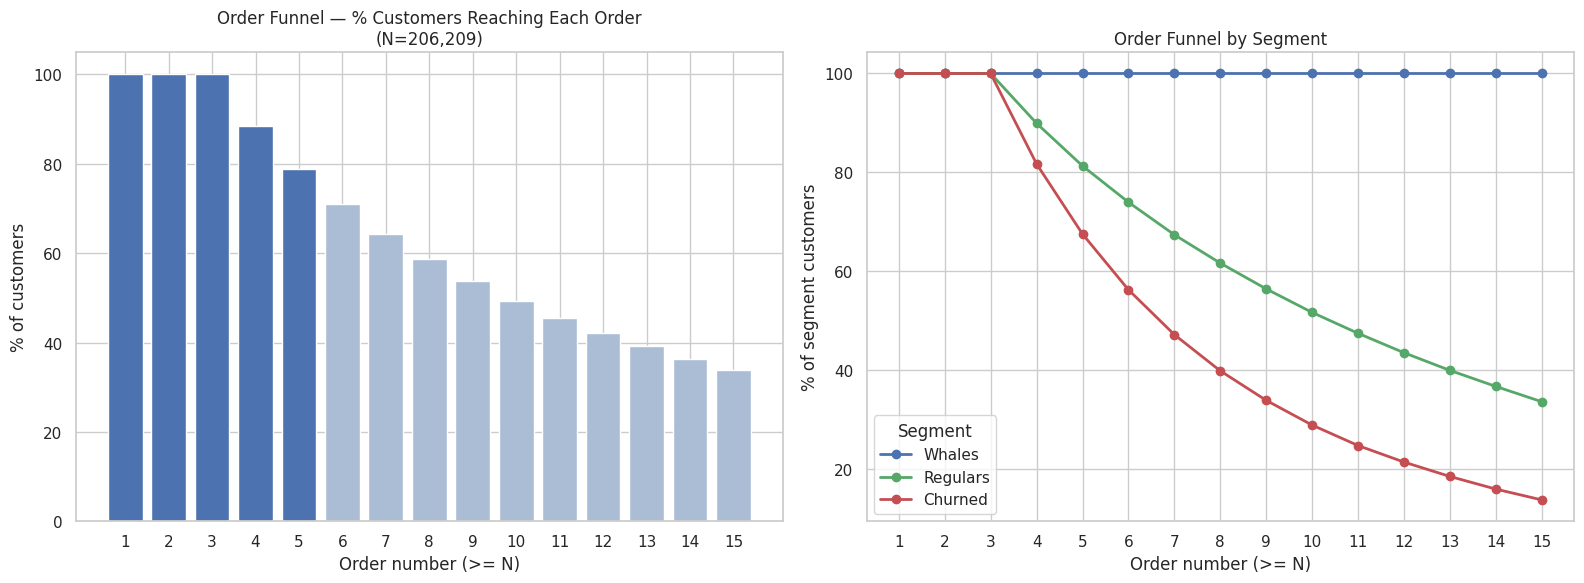

Overall funnel table:


,order_n,customers_reached,pct_of_total,drop_off_pct
0,1,206209,1.000000,0.000000
1,2,206209,1.000000,0.000000
2,3,206209,1.000000,0.116319
3,4,182223,0.883681,0.095001
4,5,162633,0.788680,0.078391
5,6,146468,0.710289,0.067165
6,7,132618,0.643124,0.056739
7,8,120918,0.586386,0.049416
8,9,110728,0.536970,0.043800
9,10,101696,0.493170,0.037898


Big drop-off points (>5%):


,order_n,pct_of_total,drop_off_pct
2,3,1.000000,0.116319
3,4,0.883681,0.095001
4,5,0.788680,0.078391
5,6,0.710289,0.067165
6,7,0.643124,0.056739


In [12]:
# --- Order Funnel ---
FUNNEL_MAX_ORDER = 15  # show up to order #15

# Customer max order number (total_orders per customer)
user_max_order = (
    df.groupby("user_id", observed=False)["order_number"]
    .max()
    .reset_index()
    .rename(columns={"order_number": "max_order"})
    .merge(rfm[["user_id", "segment"]], on="user_id", how="left")
)
user_max_order["segment"] = user_max_order["segment"].fillna("Unknown")

total_customers = user_max_order["user_id"].nunique()

# Overall funnel: % of customers with max_order >= n
funnel_steps = range(1, FUNNEL_MAX_ORDER + 1)
funnel = pd.DataFrame(
    {
        "order_n": list(funnel_steps),
        "customers_reached": [
            (user_max_order["max_order"] >= n).sum() for n in funnel_steps
        ],
    }
)
funnel["pct_of_total"] = funnel["customers_reached"] / total_customers
funnel["drop_off_pct"] = funnel["pct_of_total"].diff(-1).clip(lower=0)

# Segment funnel
seg_funnel_rows = []
for seg in SEGMENT_ORDER + ["Unknown"]:
    seg_users = user_max_order[user_max_order["segment"] == seg]
    n_seg = len(seg_users)
    if n_seg == 0:
        continue
    for n in funnel_steps:
        seg_funnel_rows.append(
            {
                "segment": seg,
                "order_n": n,
                "pct_reached": (seg_users["max_order"] >= n).sum() / n_seg,
            }
        )
seg_funnel = pd.DataFrame(seg_funnel_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall funnel bar chart
bar_colors = ["#4C72B0" if n <= 5 else "#AABDD4" for n in funnel["order_n"]]
axes[0].bar(funnel["order_n"], funnel["pct_of_total"] * 100, color=bar_colors, edgecolor="white")
axes[0].set_title(f"Order Funnel — % Customers Reaching Each Order\n(N={total_customers:,})")
axes[0].set_xlabel("Order number (>= N)")
axes[0].set_ylabel("% of customers")
axes[0].set_xticks(list(funnel_steps))

# Segment funnel line chart
seg_palette = dict(zip(SEGMENT_ORDER, ["#4C72B0", "#55A868", "#C44E52"]))
for seg in SEGMENT_ORDER:
    seg_data = seg_funnel[seg_funnel["segment"] == seg]
    if not seg_data.empty:
        axes[1].plot(
            seg_data["order_n"],
            seg_data["pct_reached"] * 100,
            marker="o",
            label=seg,
            color=seg_palette.get(seg),
            linewidth=2,
        )
axes[1].set_title("Order Funnel by Segment")
axes[1].set_xlabel("Order number (>= N)")
axes[1].set_ylabel("% of segment customers")
axes[1].set_xticks(list(funnel_steps))
axes[1].legend(title="Segment")

plt.tight_layout()
plt.show()

show_df(funnel, title="Overall funnel table:")

# Key drop-off points (drop > 5%)
big_drops = funnel[funnel["drop_off_pct"] > 0.05].copy()
show_df(big_drops[["order_n", "pct_of_total", "drop_off_pct"]], title="Big drop-off points (>5%):")

### 6.3 First Purchase Category (Gateway Category)

หา "gateway category" ที่พาลูกค้าใหม่เข้าสู่การเป็น Whales

- Top departments/aisles ในออร์เดอร์แรก (`order_number = 1`)
- เปรียบเทียบตาม segment
- Conversion insight: gateway category ไหนมีสัดส่วนกลายเป็น Whales สูง

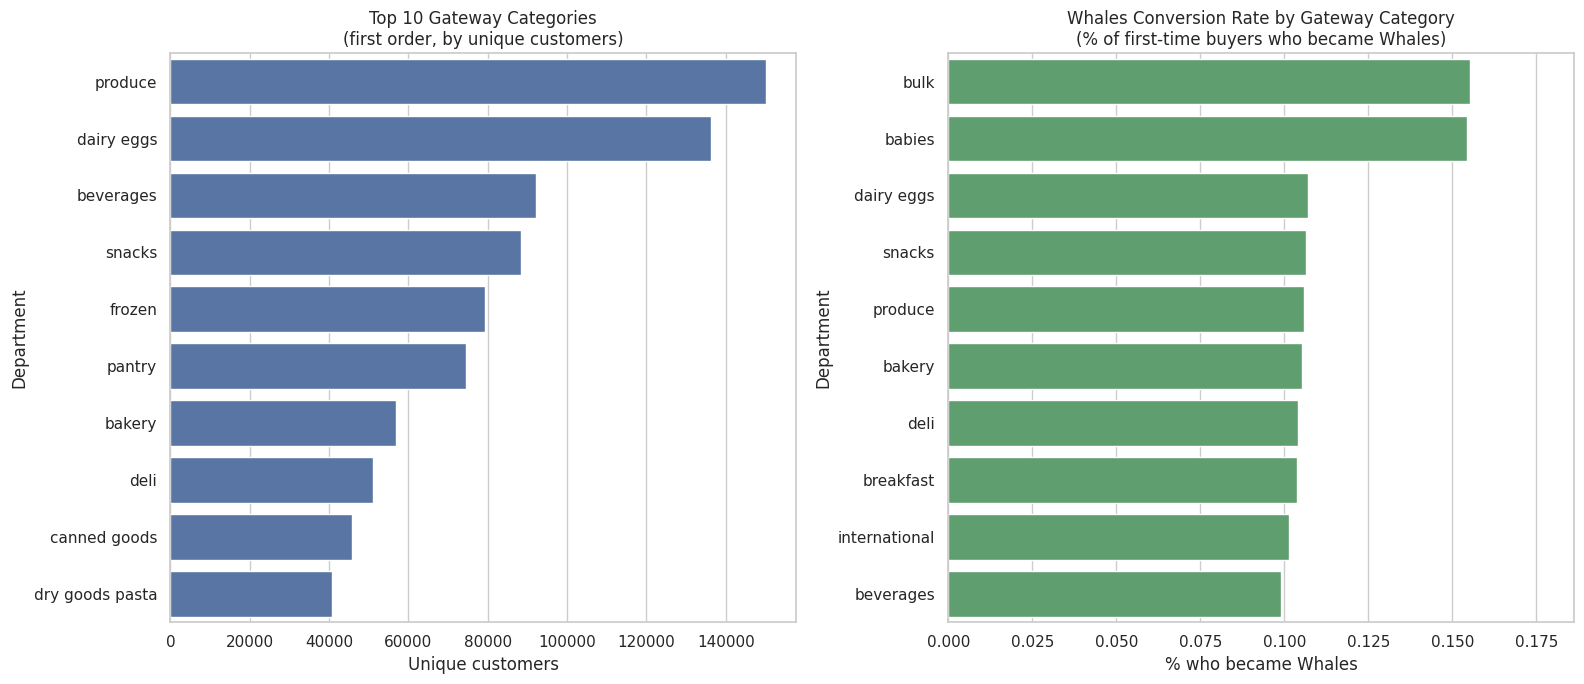

Overall top gateway categories (department):


,department,customers,order_lines,pct_of_new_customers
0,produce,150245,584384,0.728605
1,dairy eggs,136272,333030,0.660844
2,beverages,92264,167618,0.447430
3,snacks,88331,180909,0.428357
4,frozen,79311,158323,0.384615
5,pantry,74426,128268,0.360925
6,bakery,56870,75541,0.275788
7,deli,51136,70099,0.247981
8,canned goods,45911,73766,0.222643
9,dry goods pasta,40797,60982,0.197843


Top gateway categories by segment:


,segment,department,customers,pct_in_segment
0,Whales,produce,15903,0.160140
1,Whales,dairy eggs,14576,0.146777
2,Whales,snacks,9412,0.094777
3,Whales,beverages,9127,0.091907
4,Whales,frozen,7599,0.076520
5,Whales,pantry,7314,0.073650
6,Whales,bakery,5986,0.060278
7,Whales,deli,5325,0.053622
8,Whales,canned goods,4145,0.041739
9,Whales,dry goods pasta,3928,0.039554


Whales conversion rate by gateway category:


,department,whale_conversion_rate
0,bulk,0.155193
1,babies,0.154473
2,dairy eggs,0.106963
3,snacks,0.106554
4,produce,0.105847
5,bakery,0.105258
6,deli,0.104134
7,breakfast,0.103836
8,international,0.101531
9,beverages,0.098923


In [13]:
# --- First Purchase Category ---
TOP_N_GATEWAY = 10
GATEWAY_COL = "department"  # switch to "aisle" for finer granularity

first_order_df = df[df["order_number"] == 1].copy()

# Ensure gateway column exists
if GATEWAY_COL not in first_order_df.columns:
    product_dim_gw = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE, project_root=PROJECT_ROOT
    )[["product_id", GATEWAY_COL]]
    first_order_df = first_order_df.merge(product_dim_gw, on="product_id", how="left")

first_order_df[GATEWAY_COL] = first_order_df[GATEWAY_COL].fillna("Unknown")

# 1) Overall top gateway categories
gateway_overall = (
    first_order_df.groupby(GATEWAY_COL, observed=False)
    .agg(customers=("user_id", "nunique"), order_lines=("product_id", "count"))
    .reset_index()
    .sort_values("customers", ascending=False)
    .head(TOP_N_GATEWAY)
    .reset_index(drop=True)
)
gateway_overall["pct_of_new_customers"] = (
    gateway_overall["customers"] / first_order_df["user_id"].nunique()
)

# 2) Gateway by segment — robustly resolve segment from either df or rfm
segment_lookup = None
if "rfm" in globals() and isinstance(rfm, pd.DataFrame) and {"user_id", "segment"}.issubset(rfm.columns):
    segment_lookup = rfm[["user_id", "segment"]].drop_duplicates()

if segment_lookup is not None:
    first_order_seg = first_order_df.merge(
        segment_lookup,
        on="user_id",
        how="left",
        suffixes=("", "_rfm"),
    )
else:
    first_order_seg = first_order_df.copy()

segment_candidates = [
    col for col in ["segment", "segment_rfm", "segment_x", "segment_y"]
    if col in first_order_seg.columns
]
if segment_candidates:
    first_order_seg["segment"] = first_order_seg[segment_candidates].bfill(axis=1).iloc[:, 0]
else:
    first_order_seg["segment"] = "Unknown"

first_order_seg["segment"] = first_order_seg["segment"].fillna("Unknown")

gateway_by_segment = (
    first_order_seg.groupby(["segment", GATEWAY_COL], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
seg_totals = gateway_by_segment.groupby("segment", observed=False)["customers"].transform("sum")
gateway_by_segment["pct_in_segment"] = gateway_by_segment["customers"] / seg_totals

top_gateway_by_segment = (
    gateway_by_segment.sort_values(["segment", "customers"], ascending=[True, False])
    .groupby("segment", observed=False)
    .head(TOP_N_GATEWAY)
    .reset_index(drop=True)
)

# 3) Conversion: for each gateway category, what % ended up as Whales?
whales_first = (
    first_order_seg.groupby([GATEWAY_COL, "segment"], observed=False)
    .agg(customers=("user_id", "nunique"))
    .reset_index()
)
cat_totals = whales_first.groupby(GATEWAY_COL, observed=False)["customers"].transform("sum")
whales_first["pct_in_cat"] = whales_first["customers"] / cat_totals

whale_conversion = (
    whales_first[whales_first["segment"] == "Whales"]
    [[GATEWAY_COL, "pct_in_cat"]]
    .rename(columns={"pct_in_cat": "whale_conversion_rate"})
    .sort_values("whale_conversion_rate", ascending=False)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=gateway_overall,
    x="customers",
    y=GATEWAY_COL,
    color="#4C72B0",
    ax=axes[0],
)
axes[0].set_title(f"Top {TOP_N_GATEWAY} Gateway Categories\n(first order, by unique customers)")
axes[0].set_xlabel("Unique customers")
axes[0].set_ylabel(GATEWAY_COL.title())

# Whales conversion rate by gateway category (top 10)
top_whale_conv = whale_conversion.head(TOP_N_GATEWAY)
if not top_whale_conv.empty:
    sns.barplot(
        data=top_whale_conv,
        x="whale_conversion_rate",
        y=GATEWAY_COL,
        color="#55A868",
        ax=axes[1],
    )
    axes[1].set_xlim(0, top_whale_conv["whale_conversion_rate"].max() * 1.2)
else:
    axes[1].text(0.5, 0.5, "No Whale customers found", ha="center", va="center")
    axes[1].set_xlim(0, 1)

axes[1].set_title(f"Whales Conversion Rate by Gateway Category\n(% of first-time buyers who became Whales)")
axes[1].set_xlabel("% who became Whales")
axes[1].set_ylabel(GATEWAY_COL.title())

plt.tight_layout()
plt.show()

show_df(gateway_overall, title=f"Overall top gateway categories ({GATEWAY_COL}):")
show_df(top_gateway_by_segment, title="Top gateway categories by segment:")
show_df(whale_conversion, title="Whales conversion rate by gateway category:")

## 7) Trend Deep Dive (User & Product)

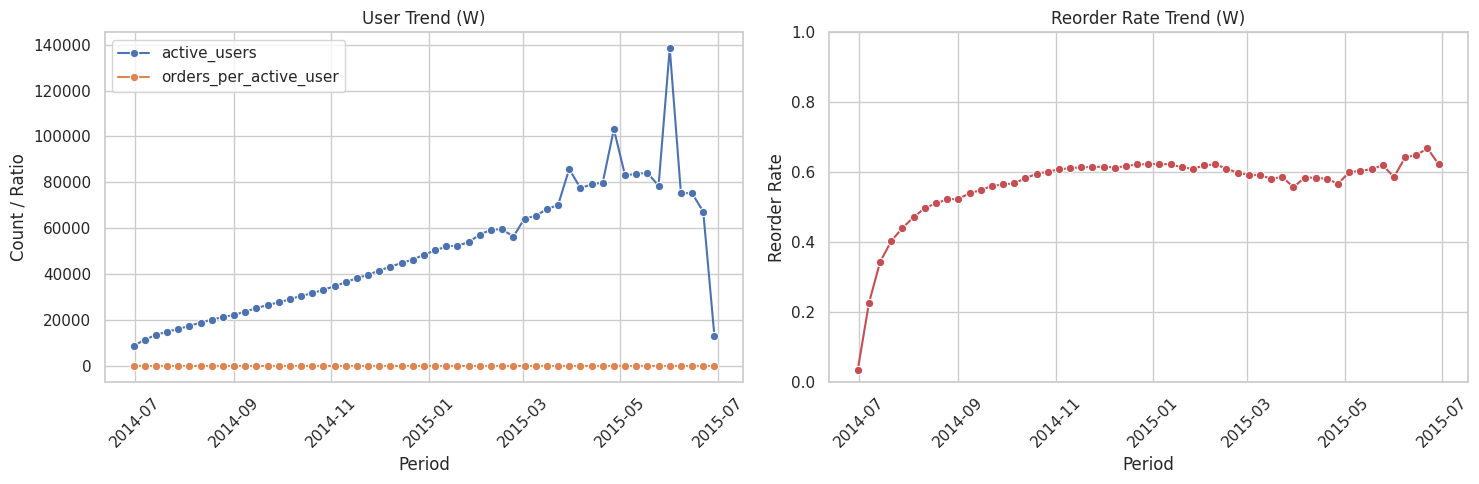

User trend summary:


,period,active_users,orders,order_lines,reorder_rate,orders_per_active_user
0,2014-06-30,8643,10692,120845,0.034706,1.237070
1,2014-07-07,11495,14844,165529,0.225695,1.291344
2,2014-07-14,13415,17413,194327,0.343220,1.298025
3,2014-07-21,15006,19334,213863,0.402992,1.288418
4,2014-07-28,16007,20508,225960,0.440361,1.281189
5,2014-08-04,17513,22421,246304,0.471072,1.280249
6,2014-08-11,18875,24163,263823,0.497318,1.280159
7,2014-08-18,20141,25668,280523,0.510368,1.274415
8,2014-08-25,21282,27130,292786,0.522119,1.274786
9,2014-09-01,22223,28226,306418,0.523422,1.270126


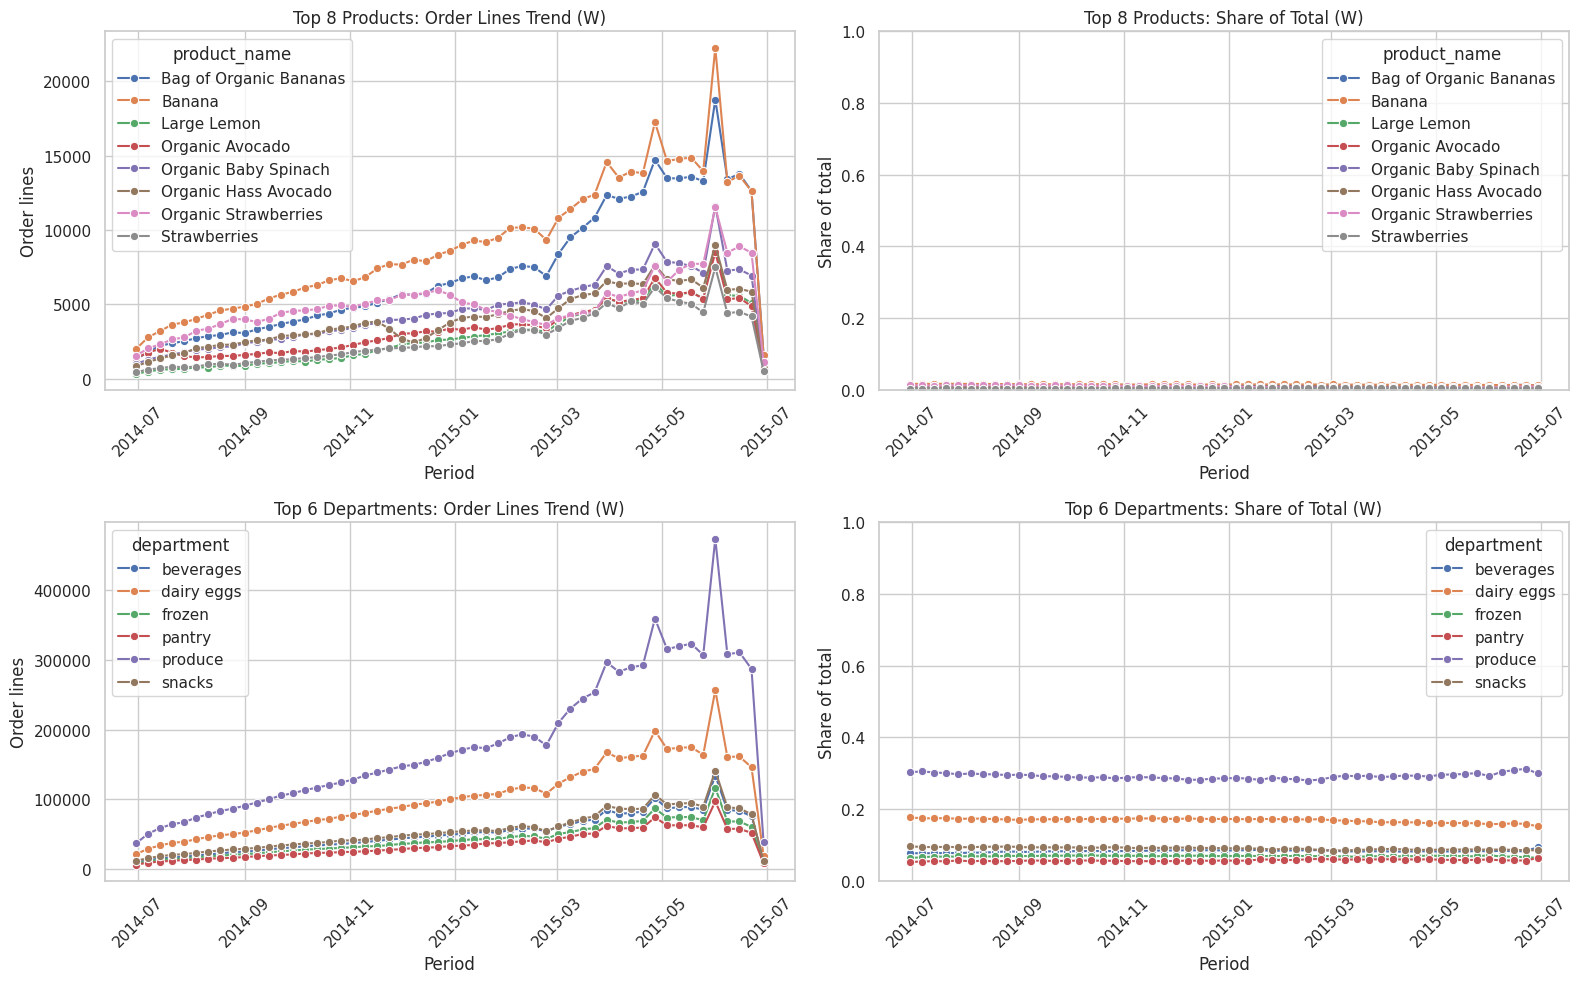

Product trend sample:


,period,product_name,order_lines,total_lines_period,share_of_total
0,2014-06-30,Bag of Organic Bananas,1302,120845,0.010774
8,2014-07-07,Bag of Organic Bananas,1776,165529,0.010729
16,2014-07-14,Bag of Organic Bananas,2221,194327,0.011429
24,2014-07-21,Bag of Organic Bananas,2367,213863,0.011068
32,2014-07-28,Bag of Organic Bananas,2525,225960,0.011175
40,2014-08-04,Bag of Organic Bananas,2716,246304,0.011027
48,2014-08-11,Bag of Organic Bananas,2853,263823,0.010814
56,2014-08-18,Bag of Organic Bananas,2931,280523,0.010448
64,2014-08-25,Bag of Organic Bananas,3112,292786,0.010629
72,2014-09-01,Bag of Organic Bananas,3057,306418,0.009977


Department trend sample:


,period,department,order_lines,total_lines_period,share_of_total
0,2014-06-30,beverages,9297,120845,0.076933
6,2014-07-07,beverages,12742,165529,0.076977
12,2014-07-14,beverages,14996,194327,0.077169
18,2014-07-21,beverages,16595,213863,0.077596
24,2014-07-28,beverages,17503,225960,0.077461
30,2014-08-04,beverages,19359,246304,0.078598
36,2014-08-11,beverages,20758,263823,0.078682
42,2014-08-18,beverages,22441,280523,0.079997
48,2014-08-25,beverages,23999,292786,0.081968
54,2014-09-01,beverages,24884,306418,0.081209


In [14]:
# --- User trend + Product trend (Top N + Share) ---
TREND_FREQ = "W"  # use "M" for monthly
TOP_N_PRODUCTS = 8
TOP_N_DEPARTMENTS = 6

trend_df = df.copy()
trend_df["period"] = trend_df["order_date"].dt.to_period(TREND_FREQ).dt.to_timestamp()

# User trend metrics
user_trend = (
    trend_df.groupby("period", observed=False)
    .agg(
        active_users=("user_id", "nunique"),
        orders=("order_id", "nunique"),
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)
user_trend["orders_per_active_user"] = user_trend["orders"] / user_trend["active_users"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=user_trend, x="period", y="active_users", marker="o", ax=axes[0], label="active_users")
sns.lineplot(data=user_trend, x="period", y="orders_per_active_user", marker="o", ax=axes[0], label="orders_per_active_user")
axes[0].set_title(f"User Trend ({TREND_FREQ})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Count / Ratio")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=user_trend, x="period", y="reorder_rate", marker="o", ax=axes[1], color="#C44E52")
axes[1].set_title(f"Reorder Rate Trend ({TREND_FREQ})")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Reorder Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(user_trend, title="User trend summary:")

# Product trend prep: ensure department exists
if "department" not in trend_df.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "department"]]
    trend_df = trend_df.merge(product_dim, on="product_id", how="left")

period_total_lines = (
    trend_df.groupby("period", observed=False)
    .size()
    .rename("total_lines_period")
    .reset_index()
)

# Top N products by overall order lines
top_products = (
    trend_df["product_name"].value_counts().head(TOP_N_PRODUCTS).index.tolist()
)
product_period = (
    trend_df[trend_df["product_name"].isin(top_products)]
    .groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
product_period["share_of_total"] = product_period["order_lines"] / product_period["total_lines_period"]

# Top N departments by overall order lines
top_departments = (
    trend_df["department"].dropna().value_counts().head(TOP_N_DEPARTMENTS).index.tolist()
)
dept_period = (
    trend_df[trend_df["department"].isin(top_departments)]
    .groupby(["period", "department"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
dept_period["share_of_total"] = dept_period["order_lines"] / dept_period["total_lines_period"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(
    data=product_period,
    x="period",
    y="order_lines",
    hue="product_name",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title(f"Top {TOP_N_PRODUCTS} Products: Order Lines Trend ({TREND_FREQ})")
axes[0, 0].set_xlabel("Period")
axes[0, 0].set_ylabel("Order lines")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=product_period,
    x="period",
    y="share_of_total",
    hue="product_name",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"Top {TOP_N_PRODUCTS} Products: Share of Total ({TREND_FREQ})")
axes[0, 1].set_xlabel("Period")
axes[0, 1].set_ylabel("Share of total")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="order_lines",
    hue="department",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Order Lines Trend ({TREND_FREQ})")
axes[1, 0].set_xlabel("Period")
axes[1, 0].set_ylabel("Order lines")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="share_of_total",
    hue="department",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Share of Total ({TREND_FREQ})")
axes[1, 1].set_xlabel("Period")
axes[1, 1].set_ylabel("Share of total")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

show_df(product_period.sort_values(["product_name", "period"]), title="Product trend sample:")
show_df(dept_period.sort_values(["department", "period"]), title="Department trend sample:")

## 8) Distribution Diagnostics (Histogram Supplements)

ใช้ histogram เพื่ออ่าน shape ของการกระจาย (ไม่ใช่ time trend)
- `days_since_prior_order`
- `orders_per_user`
- `product_growth_rate` ข้ามช่วงเวลา

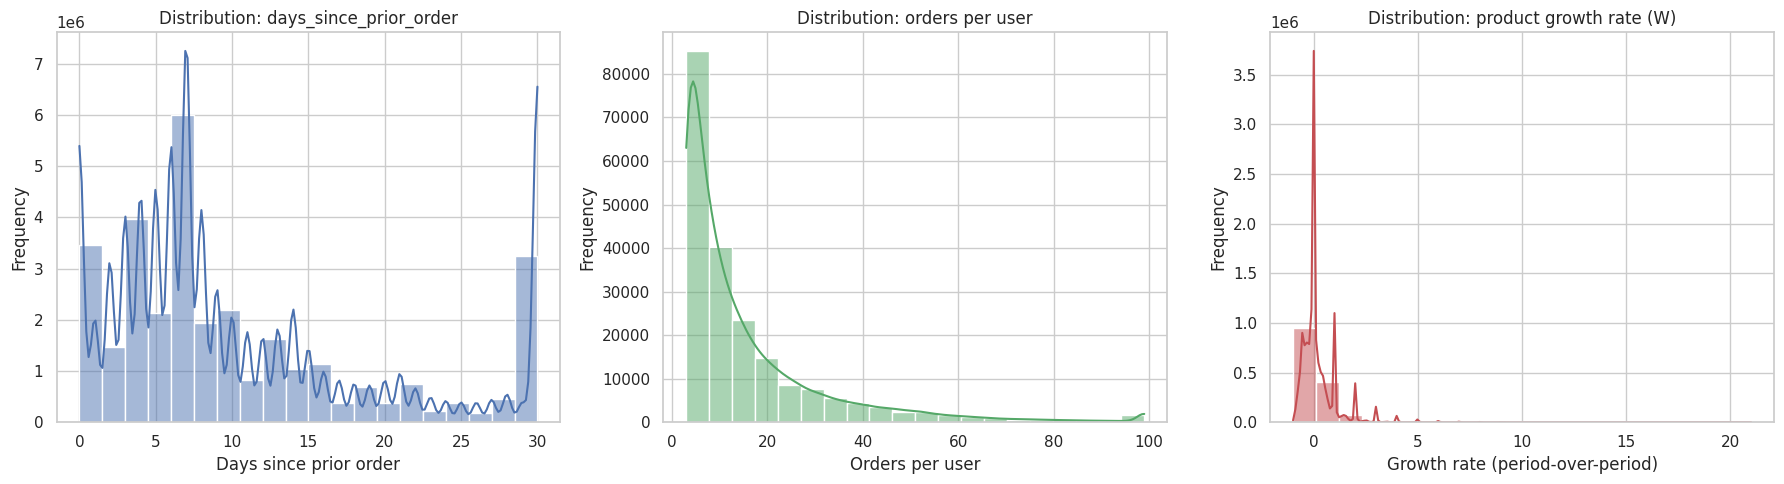

orders_per_user summary:


,orders_per_user
count,206209.000000
mean,15.590367
std,16.654774
min,3.000000
25%,5.000000
50%,9.000000
75%,19.000000
max,99.000000


product_growth_rate summary:


,product_growth_rate
count,1.464919e+06
mean,2.131134e-01
std,8.444915e-01
min,-9.838710e-01
25%,-2.500000e-01
50%,0.000000e+00
75%,4.000000e-01
max,2.100000e+01



=== Executive Summary (Quick Read) ===
Data mode: FULL DATASET
Rows: 32,434,489 | Users: 206,209 | Orders: 3,214,874
Date range: 2014-07-01 -> 2015-07-01
Segment snapshot:


,segment,users,median_total_orders,median_reorder_ratio,median_days_since_last_order,user_share
0,Whales,20024,51.0,0.727273,7.0,0.097105
1,Regulars,122999,10.0,0.431373,12.0,0.596477
2,Churned,63186,6.0,0.341463,31.0,0.306417


Top 5 products overall (order lines):


,order_lines
product_name,
Banana,472565
Bag of Organic Bananas,379450
Organic Strawberries,264683
Organic Baby Spinach,241921
Organic Hass Avocado,213584


Overall reorder rate: 58.97%
Median days_since_prior_order: 7.0


: 

In [ ]:
# --- Histogram supplements ---

# 1) Distribution of days_since_prior_order
days_dist = df["days_since_prior_order"].dropna()

# 2) Distribution of order frequency per user
user_order_freq = (
    df.groupby("user_id", observed=False)["order_id"]
    .nunique()
    .rename("orders_per_user")
)

# 3) Distribution of product growth rate between periods
growth_base = (
    trend_df.groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
growth_base = growth_base.sort_values(["product_name", "period"])
growth_base["product_growth_rate"] = growth_base.groupby("product_name", observed=False)["order_lines"].pct_change()

# Keep finite growth values for histogram
growth_values = growth_base["product_growth_rate"].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(days_dist, bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution: days_since_prior_order")
axes[0].set_xlabel("Days since prior order")
axes[0].set_ylabel("Frequency")

sns.histplot(user_order_freq, bins=20, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution: orders per user")
axes[1].set_xlabel("Orders per user")
axes[1].set_ylabel("Frequency")

sns.histplot(growth_values, bins=20, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title(f"Distribution: product growth rate ({TREND_FREQ})")
axes[2].set_xlabel("Growth rate (period-over-period)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

show_df(user_order_freq.describe().to_frame(name="orders_per_user"), title="orders_per_user summary:")
show_df(growth_values.describe().to_frame(name="product_growth_rate"), title="product_growth_rate summary:")

# --- Executive summary block (auto-refresh after re-run) ---
segment_snapshot = (
    rfm.groupby("segment", observed=False)
    .agg(
        users=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_reorder_ratio=("reorder_ratio", "median"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)
segment_snapshot["user_share"] = segment_snapshot["users"] / segment_snapshot["users"].sum()

print("\n=== Executive Summary (Quick Read) ===")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Rows: {len(df):,} | Users: {df['user_id'].nunique():,} | Orders: {df['order_id'].nunique():,}")
print(f"Date range: {df['order_date'].min().date()} -> {df['order_date'].max().date()}")
show_df(segment_snapshot, title="Segment snapshot:")

top5 = df["product_name"].value_counts().head(5).rename("order_lines").to_frame()
show_df(top5, title="Top 5 products overall (order lines):")

print("Overall reorder rate:", f"{df['reordered'].mean():.2%}")
print("Median days_since_prior_order:", f"{df['days_since_prior_order'].median():.1f}")

## 9) Executive Summary (Interpretation Template)

ใช้ checklist นี้ตอนสรุปผลประชุม/พรีเซนต์

- Segment story: Whales / Regulars / Churned ต่างกันที่อะไร (order frequency, reorder, recency)
- Time-slot story: วันและชั่วโมงไหนมีทั้ง volume และ reorder สูง
- Category story: หมวดไหน repeat สูง และหมวดไหนมูลค่าตะกร้าสูง
- Risk story: threshold churn ที่เหมาะกับธุรกิจ และ segment ไหนเสี่ยงสุด
- Action story: แผนที่ควรทำทันที 3 อย่าง (retain Whales, grow Regulars, win-back Churned)

หมายเหตุ: ให้รัน cell summary ก่อนหน้าเพื่ออัปเดตตัวเลขล่าสุดทุกครั้ง